# Install & Import

In [ ]:
!pip install optuna scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 10.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import optuna

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load the Dataset

In [ ]:
import pandas as pd

file_path =  "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

# Contoh: anggap df sudah ada
# df['clean_text'], df['encoded_label']

X = df['clean_text'].astype(str)
y = df['encoded_label']

# ==========================
# Train–Val–Test Split
# ==========================

# Step 1: Test set 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: From remaining 80%, take 12.5% as validation
# 12.5% dari 80% = 10% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1445
Validation size: 207
Test size: 414


# TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)


# Optuna Objective Function

In [ ]:
def objective(trial):

    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
    gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True) if kernel == "rbf" else "scale"

    model = SVC(
        kernel=kernel,
        C=C,
        gamma=gamma,
        probability=True,
        random_state=42
    )


    # Train on train set
    model.fit(X_train_tfidf, y_train)

    # Validate on validation set
    preds = model.predict(X_val_tfidf)

    return f1_score(y_val, preds, average="macro")

# Jalankan Optuna Study (n_trials = 50)

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)     # bisa 50–100 untuk akurasi lebih stabil


[I 2025-11-25 03:37:36,055] A new study created in memory with name: no-name-ea9f5922-aae6-450c-a1cb-ec7d8943f4cd
[I 2025-11-25 03:37:37,158] Trial 0 finished with value: 0.35514018691588783 and parameters: {'C': 1.5676930337474768, 'kernel': 'rbf', 'gamma': 0.0002950210630938502}. Best is trial 0 with value: 0.35514018691588783.
[I 2025-11-25 03:37:38,244] Trial 1 finished with value: 0.41177990183415136 and parameters: {'C': 0.17395027544985225, 'kernel': 'rbf', 'gamma': 0.36318923455310087}. Best is trial 1 with value: 0.41177990183415136.
[I 2025-11-25 03:37:39,237] Trial 2 finished with value: 0.6381118881118881 and parameters: {'C': 0.10421492234071154, 'kernel': 'linear'}. Best is trial 2 with value: 0.6381118881118881.
[I 2025-11-25 03:37:40,338] Trial 3 finished with value: 0.35514018691588783 and parameters: {'C': 0.07387444551903641, 'kernel': 'rbf', 'gamma': 0.0014794528522124773}. Best is trial 2 with value: 0.6381118881118881.
[I 2025-11-25 03:37:41,443] Trial 4 finished 

# Hyperparameter Terbaik

In [ ]:
print("Best Hyperparameters:", study.best_trial.params)


Best Hyperparameters: {'C': 1.1742448041378986, 'kernel': 'linear'}


# Train Final Model (dengan hyperparameter terbaik)

In [ ]:
best_params = study.best_trial.params

best_C = best_params["C"]
best_kernel = best_params["kernel"]
best_gamma = best_params["gamma"] if best_kernel == "rbf" else "scale"

final_model = SVC(
    C=best_C,
    kernel=best_kernel,
    gamma=best_gamma,
    probability=True,
    random_state=42
)

# Combine Train + Validation
X_final = vectorizer.fit_transform(pd.concat([X_train, X_val]))
y_final = pd.concat([y_train, y_val]).values

final_model.fit(X_final, y_final)


SVC(C=1.1742448041378986, kernel='linear', probability=True, random_state=42)

# Evaluate on Test Set

Mapping encoded_label -> class name:
0.0 -> Bullying
1.0 -> Non-bullying

Class names (urutan sesuai encoded label):
['Bullying', 'Non-bullying']

 Final Model F1 Score (Test, macro): 0.8787

 Classification Report:

              precision    recall  f1-score   support

    Bullying     0.8566    0.9430    0.8977       228
Non-bullying     0.9202    0.8065    0.8596       186

    accuracy                         0.8816       414
   macro avg     0.8884    0.8747    0.8787       414
weighted avg     0.8852    0.8816    0.8806       414



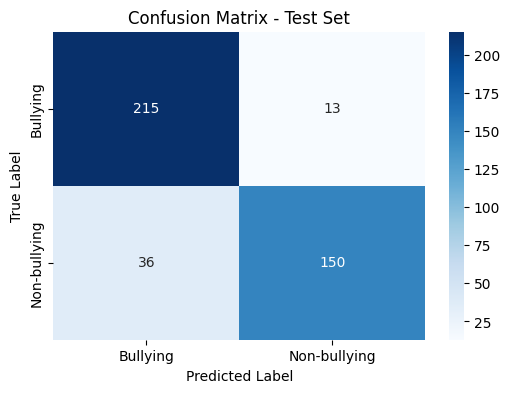

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Prediksi ---
# X_test_tfidf was generated with the vectorizer fitted on X_train only.
# The 'vectorizer' object itself was re-fitted on X_train + X_val in the previous cell.
# We need to transform X_test using the current state of the vectorizer.
y_pred = final_model.predict(vectorizer.transform(X_test))

# --- Mapping label biner ---
label_mapping = {
    0.0: "Bullying",
    1.0: "Non-bullying"
}

# Urutkan sesuai nilai encoded label
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

print("Mapping encoded_label -> class name:")
for k, v in label_mapping.items():
    print(f"{k} -> {v}")

print("\nClass names (urutan sesuai encoded label):")
print(class_names)

# --- Evaluasi ---
f1 = f1_score(y_test, y_pred, average="macro")
print(f"\n Final Model F1 Score (Test, macro): {f1:.4f}")

# Classification Report
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()

# Save Model Configuration Summary :

In [ ]:
import json
from pprint import pprint

# ------------------------------------------------------
# Experiment configuration
# ------------------------------------------------------
experiment_config = {
    "embedding": "tfidf",
    "model": "svm",
    "svm_C": best_params.get("C"),
    "svm_kernel": best_params.get("kernel"),
    "svm_gamma": best_params.get("gamma"),
    "vectorizer_params": {
        "max_features": getattr(vectorizer, "max_features", None),
        "ngram_range": getattr(vectorizer, "ngram_range", None)
    }
}

# ------------------------------------------------------
# Display configuration
# ------------------------------------------------------
print("\nExperiment Configuration:")
pprint(experiment_config)

# JSON-style print
print("\nConfiguration (JSON Format):")
print(json.dumps(experiment_config, indent=4))

# ------------------------------------------------------
# Summary of results
# ------------------------------------------------------
print("\nFinal Evaluation Summary")
print("------------------------")
print(f"Macro F1 Score (Test): {f1:.4f}")
print(f"SVM Kernel: {experiment_config['svm_kernel']}")

print()



Experiment Configuration:
{'embedding': 'tfidf',
 'model': 'svm',
 'svm_C': 1.1742448041378986,
 'svm_gamma': None,
 'svm_kernel': 'linear',
 'vectorizer_params': {'max_features': None, 'ngram_range': (1, 1)}}

Configuration (JSON Format):
{
    "embedding": "tfidf",
    "model": "svm",
    "svm_C": 1.1742448041378986,
    "svm_kernel": "linear",
    "svm_gamma": null,
    "vectorizer_params": {
        "max_features": null,
        "ngram_range": [
            1,
            1
        ]
    }
}

Final Evaluation Summary
------------------------
Macro F1 Score (Test): 0.8787
SVM Kernel: linear

